In [68]:

import numpy as np
import pandas as pd
%matplotlib Inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
sns.set_style("whitegrid")


In [80]:
df=pd.read_csv("online_retail_II.csv",parse_dates=["InvoiceDate"])

In [81]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [82]:
df.shape

(1067371, 8)

In [74]:
df["Invoice"]

0          489434
1          489434
2          489434
3          489434
4          489434
            ...  
1067366    581587
1067367    581587
1067368    581587
1067369    581587
1067370    581587
Name: Invoice, Length: 1067371, dtype: object

In [83]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [84]:
df["is_return"] = df["Invoice"].astype(str).str.startswith("C")
df = df[df["is_return"] == False]
df



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_return
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,False


In [85]:
print("Rows left after removing returns:", len(df))

Rows left after removing returns: 1047877


In [46]:
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_return
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,False


In [48]:
print("Rows left after removing bad quantity/price:", len(df))

Rows left after removing bad quantity/price: 1041670


In [86]:
df = df.dropna(subset=["Customer ID"])
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_return
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,False


In [50]:
print("Rows left after removing missing CustomerID:", len(df))

Rows left after removing missing CustomerID: 805549


In [87]:
df["LineTotal"] = df["Quantity"] * df["Price"]

df


C:\Users\mahja\AppData\Local\Temp\ipykernel_16924\357766447.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["LineTotal"] = df["Quantity"] * df["Price"]


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_return,LineTotal
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.00
...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,False,14.85


In [88]:
print("Number of unique customers remaining:", df["Customer ID"].nunique())

Number of unique customers remaining: 5881


In [89]:
most_recent_date = df["InvoiceDate"].max()
today = most_recent_date + pd.Timedelta(days=1)
print("Using this as 'today':", today)

Using this as 'today': 2011-12-10 12:50:00


In [90]:
monetary = df.groupby("Customer ID")["LineTotal"].sum()
monetary = monetary.rename("Monetary")

In [91]:
frequency = df.groupby("Customer ID")["Invoice"].nunique()
frequency = frequency.rename("Frequency")

In [92]:
last_purchase_date = df.groupby("Customer ID")["InvoiceDate"].max()
recency = (today - last_purchase_date).dt.days
recency = recency.rename("Recency")


In [93]:
rfm = pd.concat([recency, frequency, monetary], axis=1)
rfm = rfm.reset_index() 

In [94]:
spend_cutoff = rfm["Monetary"].quantile(0.99)  # the top 1% spend threshold
rfm = rfm[rfm["Monetary"] <= spend_cutoff]
print(f"Customers remaining after removing top 1% spenders: {len(rfm)}")

Customers remaining after removing top 1% spenders: 5822


In [95]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])
print("Scaling done. Each column now has an average of 0.")

Scaling done. Each column now has an average of 0.


In [96]:
NUMBER_OF_GROUPS = 4
kmeans_model = KMeans(n_clusters=NUMBER_OF_GROUPS, random_state=42, n_init=10)
group_numbers = kmeans_model.fit_predict(rfm_scaled)


In [97]:
rfm["Group"] = group_numbers
print("Done grouping. Here's how many customers are in each group:")
print(rfm["Group"].value_counts().sort_index())

Done grouping. Here's how many customers are in each group:
Group
0     831
1    1864
2     187
3    2940
Name: count, dtype: int64


In [98]:
group_summary = rfm.groupby("Group")[["Recency", "Frequency", "Monetary"]].mean()
group_summary = group_summary.round(1)
print(group_summary)


       Recency  Frequency  Monetary
Group                              
0         48.7       13.7    5516.0
1        475.9        2.0     651.6
2         31.4       32.8   15699.3
3         84.6        3.7    1136.8


In [99]:
typical_recency = group_summary["Recency"].median()
typical_monetary = group_summary["Monetary"].median()

for group_number in group_summary.index:
    avg_recency = group_summary.loc[group_number, "Recency"]
    avg_monetary = group_summary.loc[group_number, "Monetary"]
    avg_frequency = group_summary.loc[group_number, "Frequency"]

    if avg_monetary > typical_monetary and avg_recency < typical_recency:
        name = "Loyal High-Value customers -> give them a loyalty reward"
    elif avg_recency > typical_recency:
        name = "At-risk / inactive customers -> send a 'come back' discount"
    elif avg_frequency < 2:
        name = "One-time buyers -> encourage a second purchase"
    else:
        name = "Occasional shoppers -> send them more product recommendations"

    print(f"Group {group_number}: {name}")

Group 0: Loyal High-Value customers -> give them a loyalty reward
Group 1: At-risk / inactive customers -> send a 'come back' discount
Group 2: Loyal High-Value customers -> give them a loyalty reward
Group 3: At-risk / inactive customers -> send a 'come back' discount


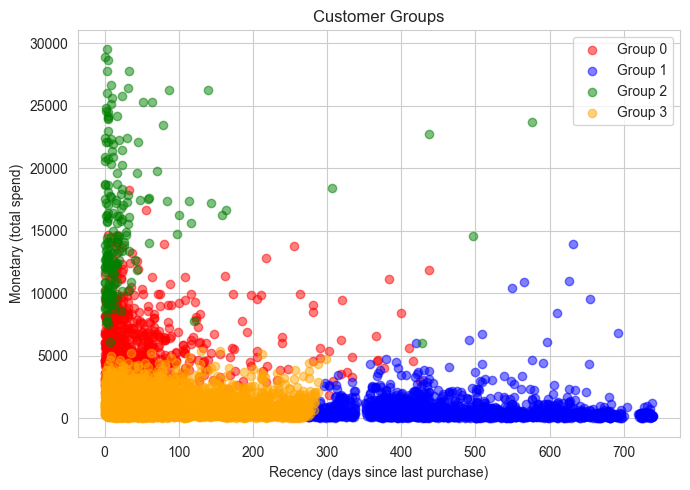

In [101]:
plt.figure(figsize=(7, 5))
colors = ["red", "blue", "green", "orange"]
for group_number in sorted(rfm["Group"].unique()):
    subset = rfm[rfm["Group"] == group_number]
    plt.scatter(subset["Recency"], subset["Monetary"],
                label=f"Group {group_number}", color=colors[group_number], alpha=0.5)

plt.xlabel("Recency (days since last purchase)")
plt.ylabel("Monetary (total spend)")
plt.title("Customer Groups")
plt.legend()
plt.tight_layout()
plt.savefig("customer_groups.pdf")
plt.show()
